# Playground to manually test a few architectures/hyperparameters
## Train LSTM pipeline and plot rolling forecasts for test profiles

In [43]:
import json

profiles = {
    "test_profiles": [
        f"results_drum_profile_{i:05d}"
        for i in range(1001, 3001)
    ]
}

with open("test_profiles_1001_3000.json", "w") as f:
    json.dump(profiles, f, indent=2)

In [37]:
from pathlib import Path
import re
import uuid

# Change this to your directory
folder = Path(r"../outputs/sim_profiles/batch_0001/")

prefix = "results_drum_profile_"
shift = -1000
digits = 5

dry_run = False  # Set to False after checking the preview

pattern = re.compile(rf"^{re.escape(prefix)}(\d{{{digits}}})$")

renames = []

for path in folder.iterdir():
    if not path.is_file():
        continue

    match = pattern.match(path.stem)
    if not match:
        continue

    old_index = int(match.group(1))
    new_index = old_index + shift

    if new_index < 0:
        raise ValueError(f"Skipping would create negative index: {path.name}")

    new_name = f"{prefix}{new_index:0{digits}d}{path.suffix}"
    new_path = path.with_name(new_name)

    renames.append((path, new_path))

# Preview
for old_path, new_path in renames:
    print(f"{old_path.name}  ->  {new_path.name}")

if dry_run:
    print("\nDry run only. Set dry_run = False to actually rename files.")
else:
    # Collision check
    original_paths = {old.resolve() for old, _ in renames}
    for old_path, new_path in renames:
        if new_path.exists() and new_path.resolve() not in original_paths:
            raise FileExistsError(f"Target already exists: {new_path}")

    # Two-pass rename to avoid conflicts
    temp_suffix = f".rename_tmp_{uuid.uuid4().hex}"
    temp_paths = []

    for old_path, new_path in renames:
        temp_path = old_path.with_name(old_path.name + temp_suffix)
        old_path.rename(temp_path)
        temp_paths.append((temp_path, new_path))

    for temp_path, new_path in temp_paths:
        temp_path.rename(new_path)

    print(f"\nRenamed {len(renames)} files.")

results_drum_profile_01001.csv  ->  results_drum_profile_00001.csv
results_drum_profile_01001.mat  ->  results_drum_profile_00001.mat
results_drum_profile_01002.csv  ->  results_drum_profile_00002.csv
results_drum_profile_01002.mat  ->  results_drum_profile_00002.mat
results_drum_profile_01003.csv  ->  results_drum_profile_00003.csv
results_drum_profile_01003.mat  ->  results_drum_profile_00003.mat
results_drum_profile_01004.csv  ->  results_drum_profile_00004.csv
results_drum_profile_01004.mat  ->  results_drum_profile_00004.mat
results_drum_profile_01005.csv  ->  results_drum_profile_00005.csv
results_drum_profile_01005.mat  ->  results_drum_profile_00005.mat
results_drum_profile_01006.csv  ->  results_drum_profile_00006.csv
results_drum_profile_01006.mat  ->  results_drum_profile_00006.mat
results_drum_profile_01007.csv  ->  results_drum_profile_00007.csv
results_drum_profile_01007.mat  ->  results_drum_profile_00007.mat
results_drum_profile_01008.csv  ->  results_drum_profile_00008

In [1]:
from pathlib import Path

from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
    save_forecast_profiles_pdf,
    compute_and_save_rolling_forecast_metrics,
)

In [7]:
batch_size = 64
epochs = 50
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = 64              # shared across stacked layers
lstm_dropout = 0.0           # ignored if n_lstm == 1 in nn.LSTM

n_fc = 2
fc_hidden = (64, 64)

learning_rate = 3e-4
preload_training_data = True


h5_path = Path("../outputs/datasets/scaled_split/lstm_merged_batches_0001-0021_k12_minmax_train2000profiles_val1000profiles_test2000profiles.h5")
out_dir = Path(f"../outputs/ml_results/training_playground/Batch0001-0021_train2000_k12_minmax-TUNED-more")
out_dir.mkdir(parents=True, exist_ok=True)

print("h5_path exists:", h5_path.exists())
print("out_dir:", out_dir)

h5_path exists: True
out_dir: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more


In [9]:
config = LSTMPipelineConfig(
    h5_path=h5_path,
    batch_size=batch_size,
    seed=seed,
    n_lstm=n_lstm,
    lstm_hidden=lstm_hidden,
    lstm_dropout=lstm_dropout,
    n_fc=n_fc,
    fc_hidden=tuple(fc_hidden),
    learning_rate=learning_rate,
    use_tqdm=True,
)

pipeline = LSTMPipeline(config)

datasets = pipeline.build()
pipeline.inspect()

Dataset summary:
  H5 path:         ..\outputs\datasets\scaled_split\lstm_merged_batches_0001-0021_k12_minmax_train2000profiles_val1000profiles_test2000profiles.h5
  Batch size:      64
  Seed:            123

  Train profiles:  2000
  Val profiles:    1000
  Test profiles:   2000

  Sample X shape:  (501, 13, 16)   (per-sample)
  Sample Y shape:  (501, 15)   (per-sample)

  Train samples:   1,002,000  (~15,657 batches)
  Val samples:     501,000  (~7,829 batches)
  Test samples:    1,002,000  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          15657
    val_samples:    7829
    val_profile_ds: 1000
    test_profile_ds:2000

Train batch X shape: torch.Size([64, 13, 16])
Train batch Y shape: torch.Size([64, 15])

Val profile: results_drum_profile_00001
  X profile shape: torch.Size([501, 13, 16])
  Y profile shape: torch.Size([501, 15])

Test profile: results_drum_profile_01001
  X profile shape: torch.Size([501, 13, 16])
  Y prof

Using GPU: NVIDIA GeForce RTX 4060 Ti

Deterministic seed set to: 123
Dataset summary: train_samples=1,002,000, val_samples=501,000, test_profiles=2,000
LSTMRegressor architecture:
  Input features: 16
  LSTM layers (1): hidden_size=64, dropout=0.0
  FC layers (2): [64, 64]
  Output targets: 15



Preloading train batches: 15657batch [00:11, 1308.99batch/s]


Preloaded 15657 training batches to cuda:0 in 11.96s.


Train 1/50: 100%|██████████| 15657/15657 [00:38<00:00, 403.60batch/s, loss=3.36010e-06]
Val 1/50: 7829batch [00:10, 744.28batch/s]


Epoch 1/50 - loss: 8.81145e-04 - val_loss: 7.97001e-06 - lr: 3.000e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 31.87s - val_time: 10.52s - epoch_total: 42.57s - preloaded: True - preload_time: 11.96s - val_preloaded: False - val_preload_time: 0.00s - max_cuda_mem: 935.40 MB - io_h5: 5.26s - io_cast: 0.12s - io_profiles: 2001 - io_samples: 1002064 - io_tput: 186395.84 samp/s - io_frac_of_data_wait: 3084.06%
Epoch 1/50 total_time_s: 42.57


...

Epoch 42/50 - loss: 1.08948e-07 - val_loss: 9.07398e-08 - lr: 1.500e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 31.83s - val_time: 10.29s - epoch_total: 42.30s - preloaded: True - preload_time: 11.96s - val_preloaded: False - val_preload_time: 0.00s - max_cuda_mem: 935.40 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 42/50 total_time_s: 42.30
Early stopping check: 8/10 epochs without validation improvement.


Train 43/50: 100%|██████████| 15657/15657 [00:38<00:00, 403.68batch/s, loss=3.75608e-07]
Val 43/50: 7829batch [00:10, 760.25batch/s]


Epoch 43/50 - loss: 1.04243e-07 - val_loss: 3.39201e-07 - lr: 1.500e-04 - data_wait: 0.18s - h2d: 0.00s - compute: 31.82s - val_time: 10.30s - epoch_total: 42.30s - preloaded: True - preload_time: 11.96s - val_preloaded: False - val_preload_time: 0.00s - max_cuda_mem: 935.40 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 43/50 total_time_s: 42.30
Early stopping check: 9/10 epochs without validation improvement.


Train 44/50: 100%|██████████| 15657/15657 [00:38<00:00, 402.75batch/s, loss=2.14925e-08]
Val 44/50: 7829batch [00:10, 759.37batch/s]


Epoch 44/50 - loss: 1.11591e-07 - val_loss: 5.99057e-08 - lr: 1.500e-04 - data_wait: 0.17s - h2d: 0.00s - compute: 31.93s - val_time: 10.31s - epoch_total: 42.42s - preloaded: True - preload_time: 11.96s - val_preloaded: False - val_preload_time: 0.00s - max_cuda_mem: 935.40 MB - io_h5: 0.00s - io_cast: 0.00s - io_profiles: 0 - io_samples: 0 - io_tput: 0.00 samp/s - io_frac_of_data_wait: 0.00%
Epoch 44/50 total_time_s: 42.42
Early stopping check: 10/10 epochs without validation improvement.
Early stopping triggered at epoch 44; best validation loss was 7.74194e-08 at epoch 34.
Restored best model weights from epoch 34.
Saved training curves to ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\lstm_train_val_curve.png
Saved learning-rate curve to ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\lstm_lr_curve.png

Timing summary (cumulative):
  preload_time: 11.96s
  val_preload_time: 0.00s
  train_data_wait_t

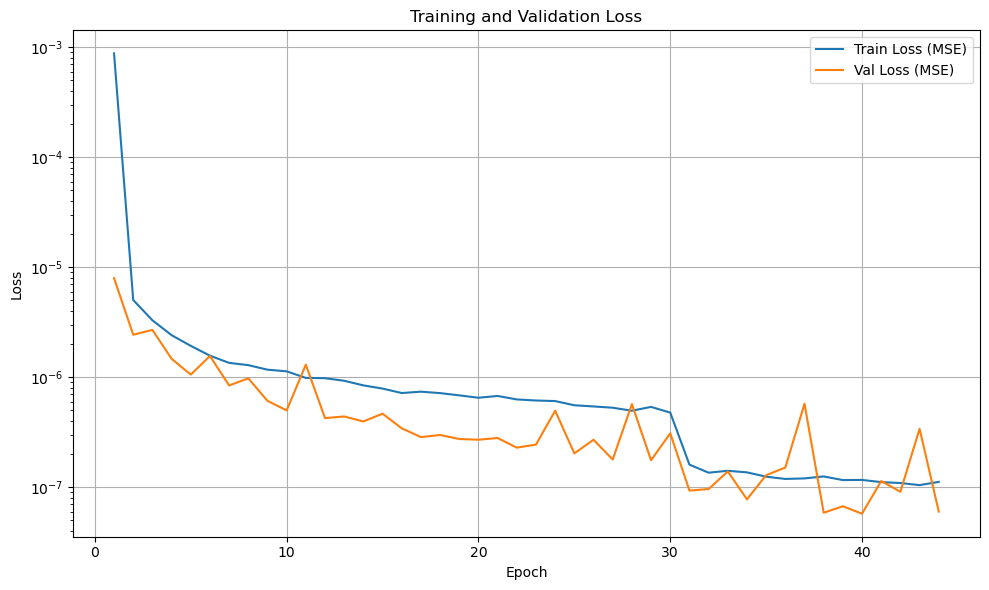

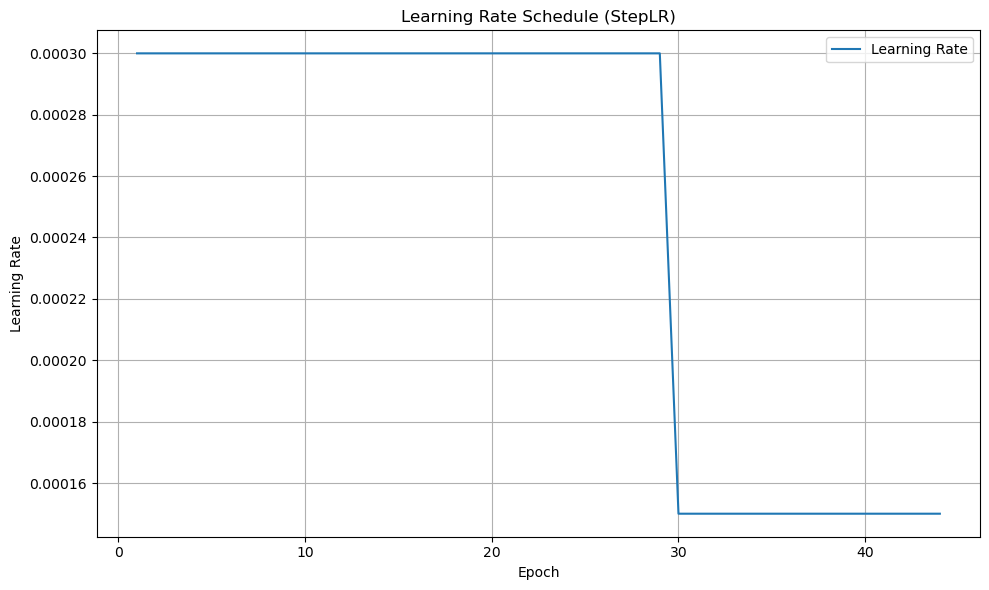

In [11]:
model, history, used_device = pipeline.train(
    epochs=epochs,
    out_dir=out_dir,
    preload_train_to_device=preload_training_data,
    early_stopping_min_delta=1e-7,
    early_stopping_patience=10,
    restore_best_weights=True,
    step_lr_step_size=30,
    step_lr_gamma=0.5,

    # --- profiler options ---
    # enable_torch_profiler=True,
    # profiler_wait_steps=5,
    # profiler_warmup_steps=3,
    # profiler_active_steps=10,
    # profiler_repeat=2,
    # profiler_row_limit=50,
)
print(f"Finished training using device: {used_device}")

In [12]:
test_and_save_forecasts(
    model,
    datasets["test_profile_ds"],
    out_dir=out_dir,
    state_dim=pipeline.config.state_dim,
    control_channel=pipeline.config.control_channel,
    target_names=pipeline.config.target_names,
    max_plots=max_plots,
    plot_callback=pipeline.plot,
    h5_path=h5_path,
)

pt_path = out_dir / "model.pt"
pipeline.save_model_pt(model, pt_path)
print(f"Saved model weights to: {pt_path}")

if "cuda" in str(used_device).lower():
    print(f"Clearing {used_device}...")
    del model
    clear_cuda_cache()

Forecast profiles: 2profile [00:10,  5.06s/profile, mae_avg=3.635957e+00]

Saved forecast plot to: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\rolling_forecast_results_drum_profile_01020.png


Forecast profiles: 3profile [00:14,  4.48s/profile, mae_avg=3.025133e+00]

Saved forecast plot to: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\rolling_forecast_results_drum_profile_01013.png


Forecast profiles: 4profile [00:18,  4.17s/profile, mae_avg=1.865776e+00]

...

Saved forecast plot to: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\rolling_forecast_results_drum_profile_01018.png


Forecast profiles: 71profile [00:25,  3.85s/profile, mae_avg=2.209889e+00]

Saved forecast plot to: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\rolling_forecast_results_drum_profile_01009.png


Forecast profiles: 2000profile [06:22,  5.23profile/s, mae_avg=2.172202e+00]



Testing timing summary: total_fetch: 0.0000s -  total_test: 1526.3182s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.7632s -  save_time: 0.9280s

Saved model weights to: ..\outputs\ml_results\training_playground\Batch0001-0021_train2000_k12_minmax-TUNED-more\model.pt
Clearing cuda:0...


In [13]:
forecast_h5_path = out_dir / "rolling_forecasts.h5"
output_pdf_path  = out_dir / "rolling_forecasts.pdf"
output_json_path = out_dir / "rolling_forecasts.json"

# save_forecast_profiles_pdf(
#     forecast_h5_path=forecast_h5_path,
#     output_pdf_path=output_pdf_path,
# )

rolling_forecasts_json = compute_and_save_rolling_forecast_metrics(
    forecast_h5_path=forecast_h5_path, 
    output_json_path=output_json_path,
)


Starting training case: train30
h5_path: C:\Users\Logan\Desktop\GitHub\RABL\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k12_minmax_train30profiles_val1000profiles_test2000profiles.h5
h5_path exists: True
out_dir: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_30trainprofiles_k12_minmax
Dataset summary:
  H5 path:         C:\Users\Logan\Desktop\GitHub\RABL\outputs\datasets\scaled_split\lstm_merged_batches_0001-0002_k12_minmax_train30profiles_val1000profiles_test2000profiles.h5
  Batch size:      128
  Seed:            123

  Train profiles:  30
  Val profiles:    1000
  Test profiles:   2000

  Sample X shape:  (501, 13, 16)   (per-sample)
  Sample Y shape:  (501, 15)   (per-sample)

  Train samples:   15,030  (~118 batches)
  Val samples:     501,000  (~3,915 batches)
  Test samples:    1,002,000  (profiles used for forecasting)

  loader cardinality (derived from precomputed counts):
    train:          118
    val_samples:   

Forecast profiles: 1profile [00:02,  2.32s/profile, mae_avg=8.300609e+00]

Saved forecast plot to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_30trainprofiles_k12_minmax\rolling_forecast_results_drum_profile_01001.png


Forecast profiles: 2profile [00:04,  2.27s/profile, mae_avg=5.831875e+00]

Saved forecast plot to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_30trainprofiles_k12_minmax\rolling_forecast_results_drum_profile_01002.png


...

Saved forecast plot to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_90trainprofiles_k12_minmax\rolling_forecast_results_drum_profile_01004.png


Forecast profiles: 5profile [00:11,  2.26s/profile, mae_avg=4.426208e+00]

Saved forecast plot to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_90trainprofiles_k12_minmax\rolling_forecast_results_drum_profile_01005.png


Forecast profiles: 2000profile [08:33,  3.89profile/s, mae_avg=3.434278e+00]



Testing timing summary: total_fetch: 0.0010s -  total_test: 485.6954s -  avg_fetch_profile: 0.0000s -  avg_inference_profile: 0.2428s -  save_time: 0.9418s

Saved model weights to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_90trainprofiles_k12_minmax\model.pt
Saved rolling forecast metrics to: C:\Users\Logan\Desktop\GitHub\RABL\outputs\ml_results\training_playground\Batch0001-0002_90trainprofiles_k12_minmax\rolling_forecasts.json
Clearing cuda:0...
Finished training case: train90

All requested training cases completed.


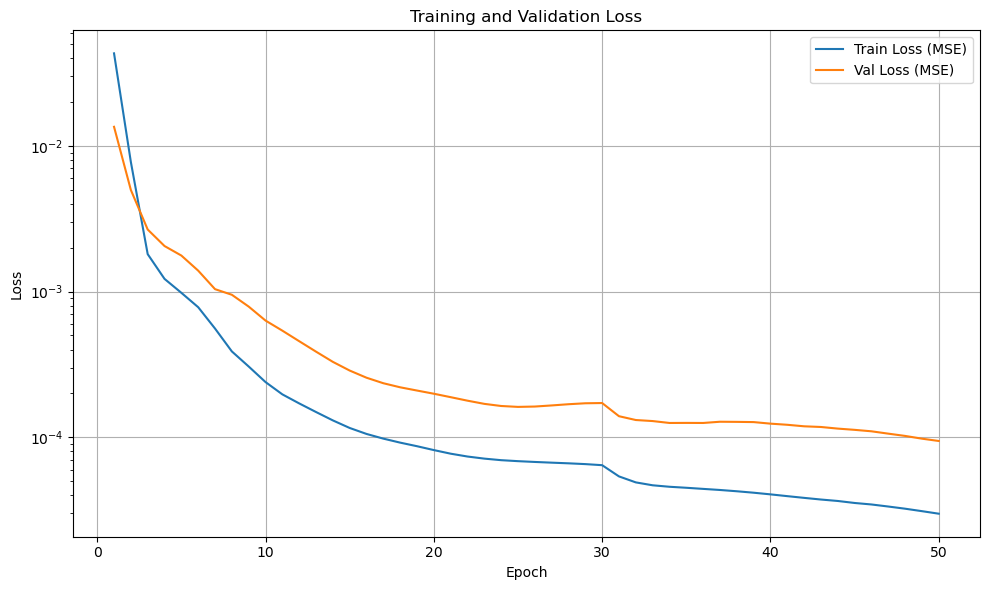

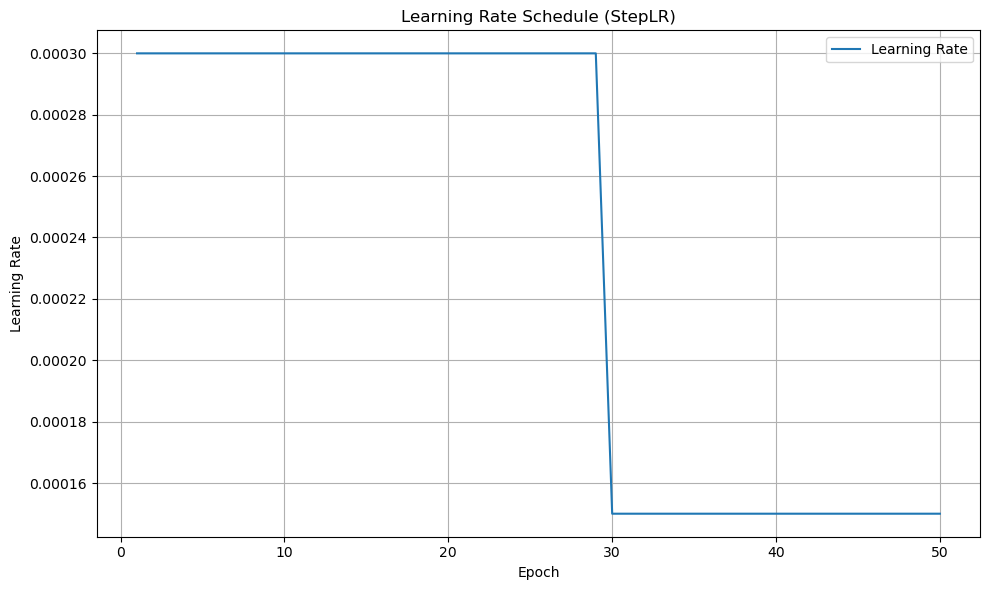

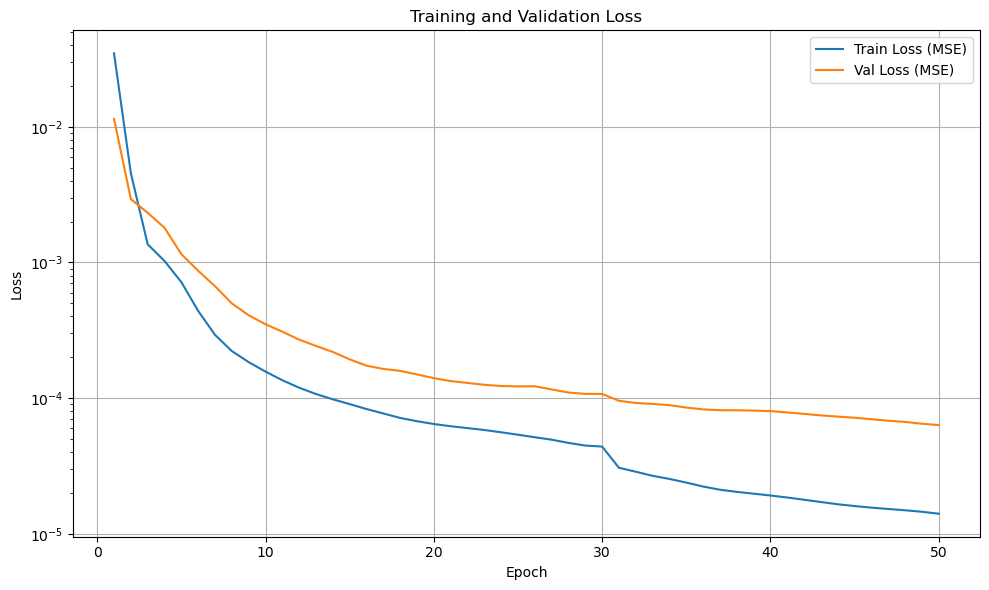

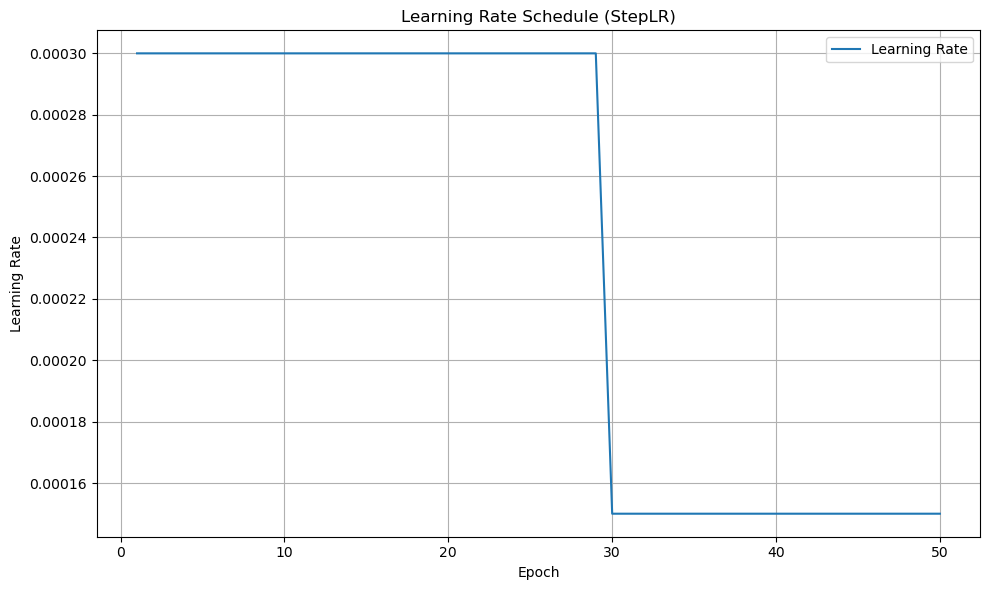

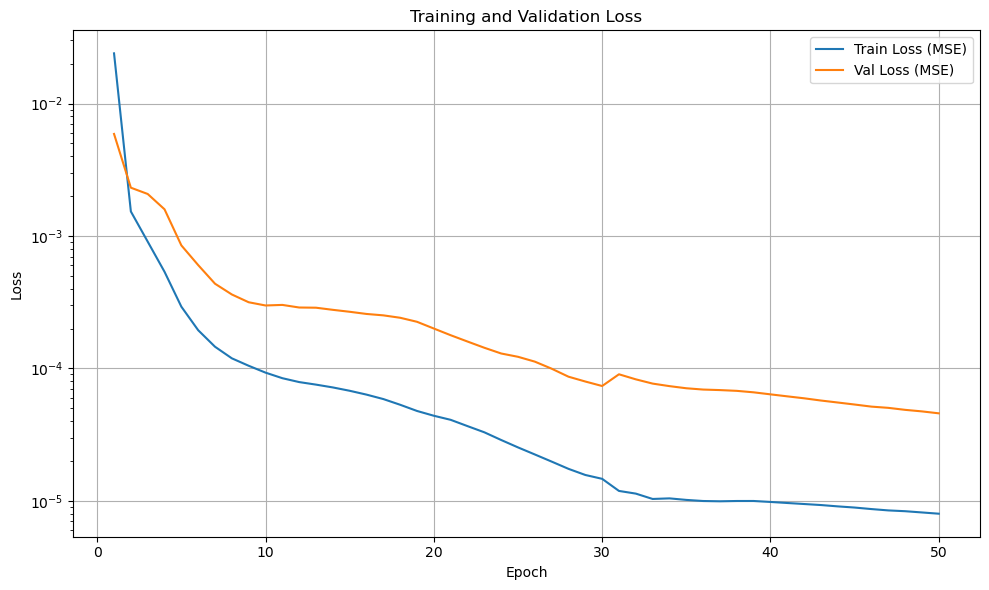

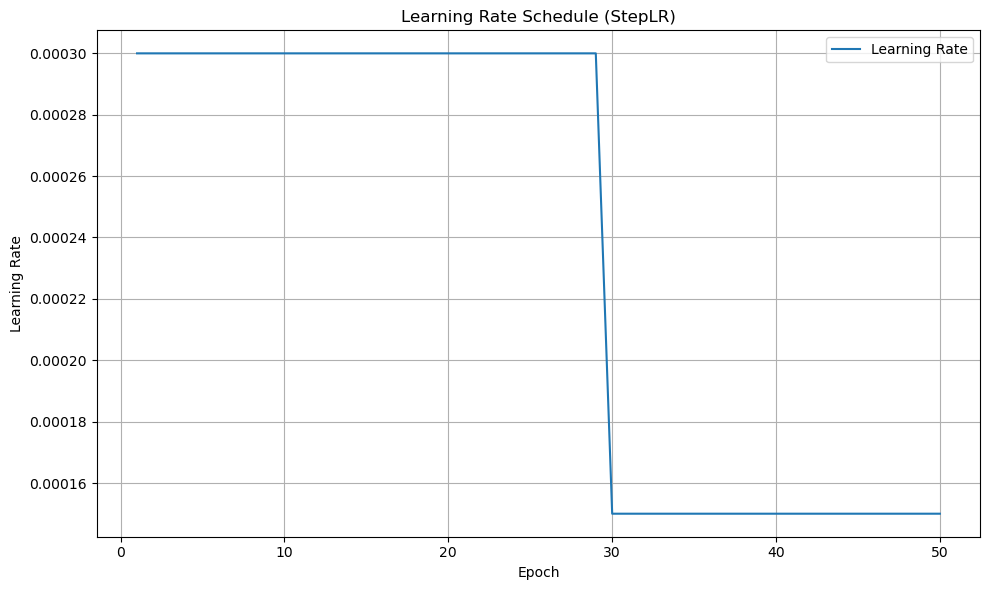

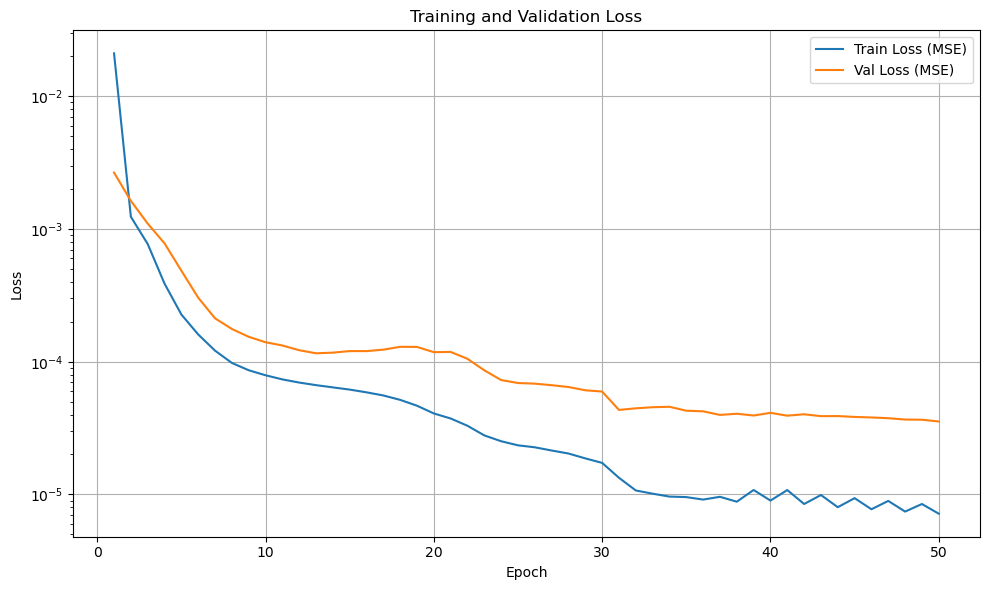

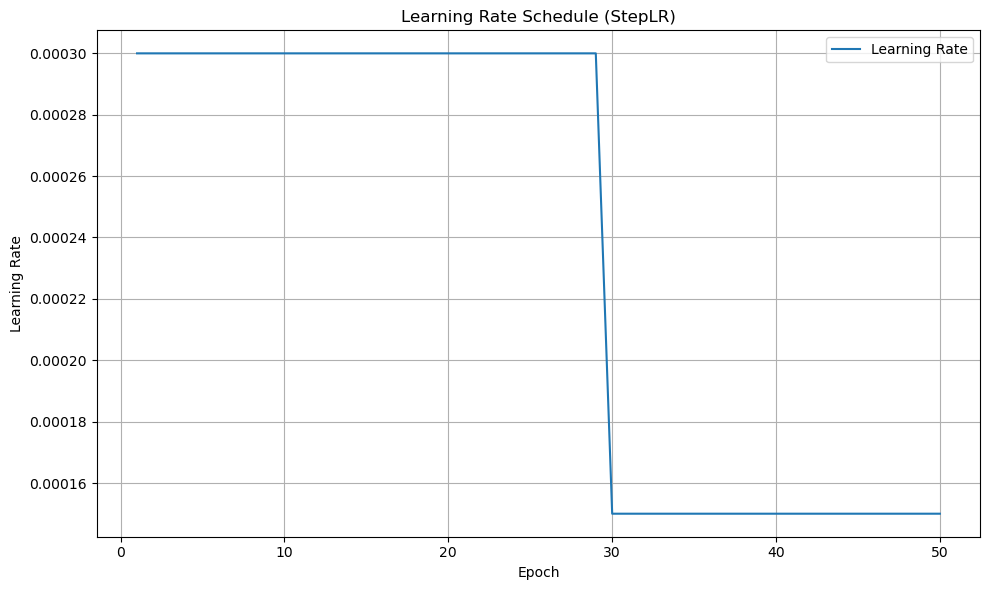

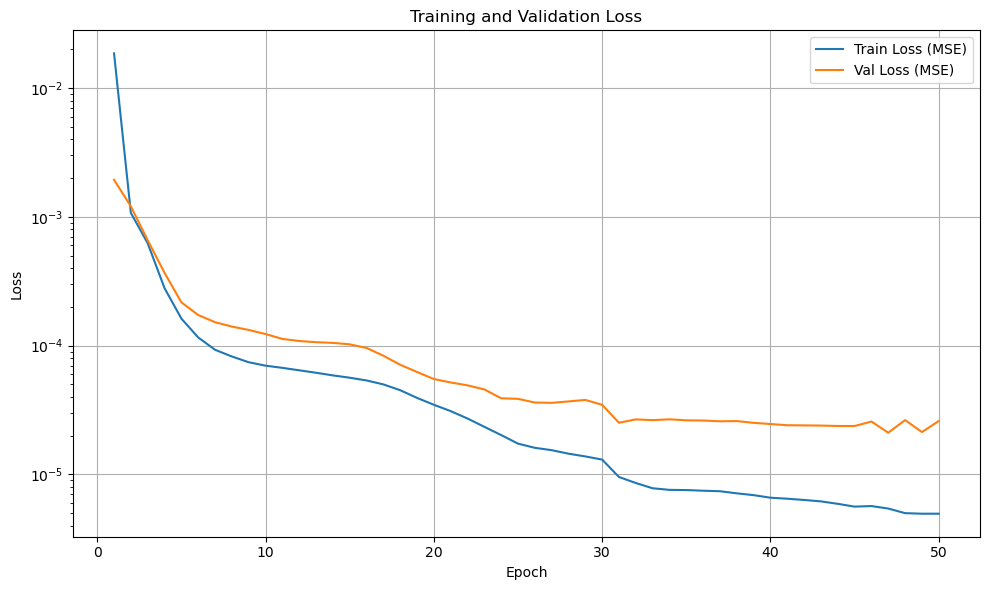

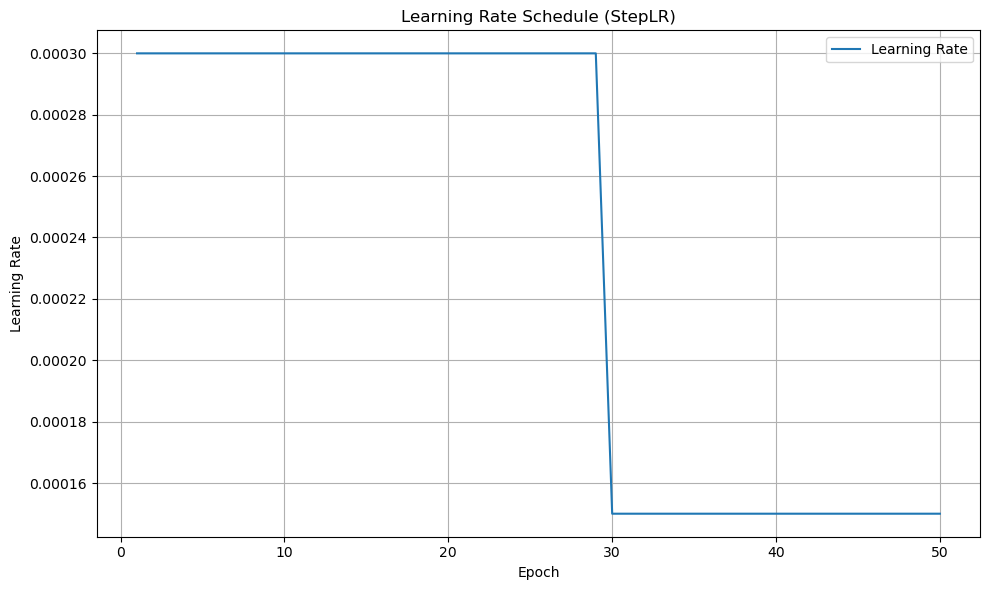

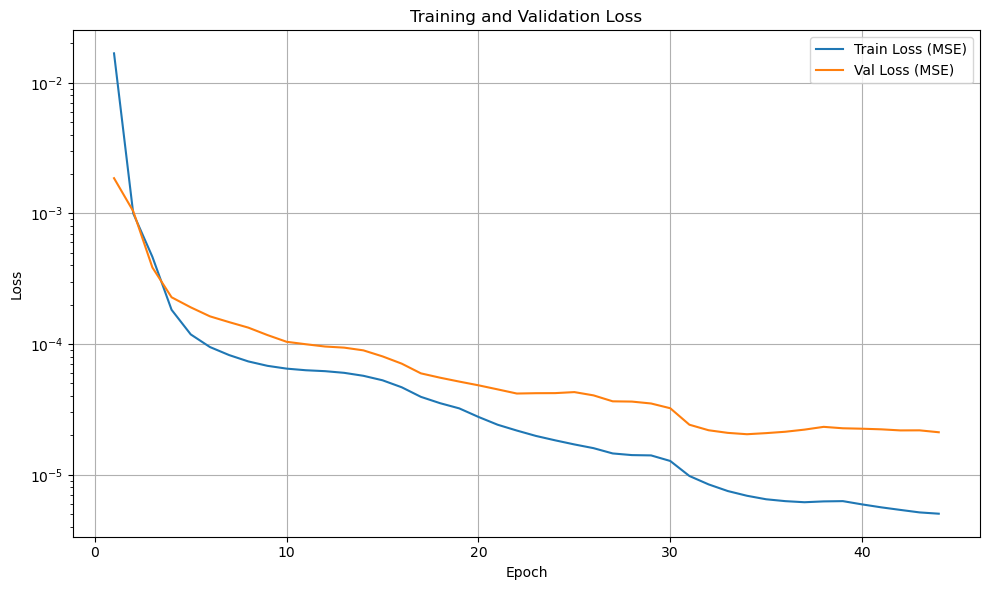

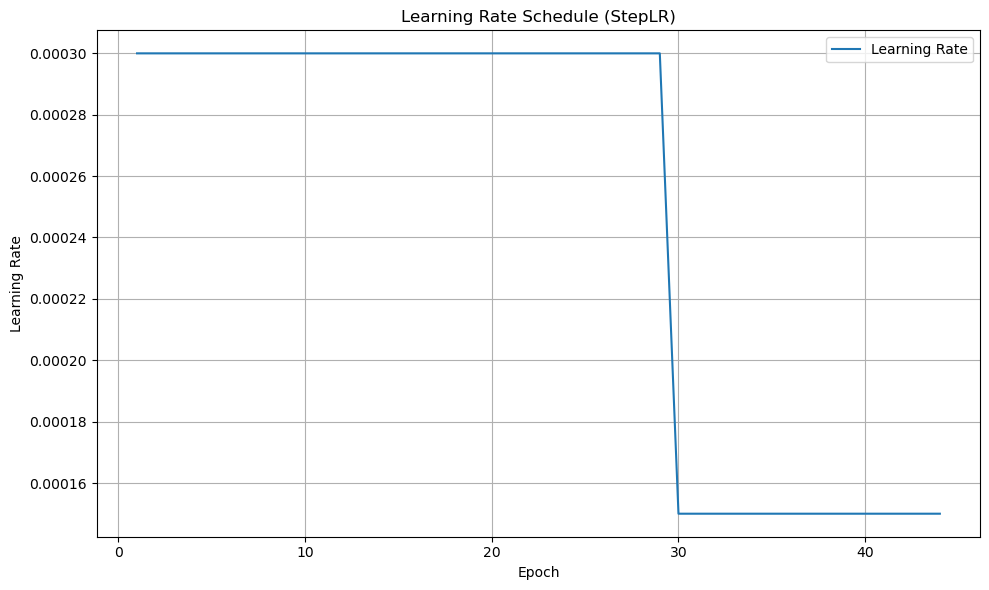

In [2]:
from pathlib import Path
import sys
import gc


# =============================================================================
# Locate repo root
# =============================================================================

def find_repo_root() -> Path:
    here = Path.cwd().resolve()

    candidates = [
        here,
        here.parent,
        here.parent.parent,
    ]

    for candidate in candidates:
        if (candidate / "outputs").exists() and (candidate / "src").exists():
            return candidate

    raise FileNotFoundError(
        "Could not locate repo root. Run this from the repo root, scripts/, or notebooks/."
    )


repo_root = find_repo_root()

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))


from rabl.machine_learning.lstm_pipeline import (
    LSTMPipeline,
    LSTMPipelineConfig,
    test_and_save_forecasts,
    clear_cuda_cache,
    compute_and_save_rolling_forecast_metrics,
)


# =============================================================================
# Training settings
# =============================================================================

train_profile_counts = [30, 40, 60, 70, 80, 90]

batch_size = 128
epochs = 50
seed = 123
max_plots = 5

n_lstm = 1
lstm_hidden = 64
lstm_dropout = 0.0

n_fc = 1
fc_hidden = (384,)

learning_rate = 3e-4
preload_training_data = True

skip_existing = True


# =============================================================================
# Training function
# =============================================================================

def train_one_case(train_profiles: int) -> None:
    h5_path = (
        repo_root
        / "outputs"
        / "datasets"
        / "scaled_split"
        / f"lstm_merged_batches_0001-0002_k12_minmax_train{train_profiles}profiles_val1000profiles_test2000profiles.h5"
    )

    out_dir = (
        repo_root
        / "outputs"
        / "ml_results"
        / "training_playground"
        / f"Batch0001-0002_{train_profiles}trainprofiles_k12_minmax"
    )

    out_dir.mkdir(parents=True, exist_ok=True)

    output_json_path = out_dir / "rolling_forecasts.json"
    if skip_existing and output_json_path.exists():
        print("\n" + "=" * 100)
        print(f"Skipping train{train_profiles}: output already exists")
        print(output_json_path)
        print("=" * 100)
        return

    print("\n" + "=" * 100)
    print(f"Starting training case: train{train_profiles}")
    print(f"h5_path: {h5_path}")
    print(f"h5_path exists: {h5_path.exists()}")
    print(f"out_dir: {out_dir}")
    print("=" * 100)

    if not h5_path.exists():
        raise FileNotFoundError(f"Missing HDF5 file: {h5_path}")

    config = LSTMPipelineConfig(
        h5_path=h5_path,
        batch_size=batch_size,
        seed=seed,
        n_lstm=n_lstm,
        lstm_hidden=lstm_hidden,
        lstm_dropout=lstm_dropout,
        n_fc=n_fc,
        fc_hidden=tuple(fc_hidden),
        learning_rate=learning_rate,
        use_tqdm=False,
    )

    pipeline = LSTMPipeline(config)

    datasets = pipeline.build()
    pipeline.inspect()

    model, history, used_device = pipeline.train(
        epochs=epochs,
        out_dir=out_dir,
        preload_train_to_device=preload_training_data,
        early_stopping_min_delta=1e-7,
        early_stopping_patience=10,
        restore_best_weights=True,
        step_lr_step_size=30,
        step_lr_gamma=0.5,
    )

    print(f"Finished training using device: {used_device}")

    test_and_save_forecasts(
        model,
        datasets["test_profile_ds"],
        out_dir=out_dir,
        state_dim=pipeline.config.state_dim,
        control_channel=pipeline.config.control_channel,
        target_names=pipeline.config.target_names,
        max_plots=max_plots,
        plot_callback=pipeline.plot,
        h5_path=h5_path,
    )

    pt_path = out_dir / "model.pt"
    pipeline.save_model_pt(model, pt_path)
    print(f"Saved model weights to: {pt_path}")

    forecast_h5_path = out_dir / "rolling_forecasts.h5"
    output_json_path = out_dir / "rolling_forecasts.json"

    compute_and_save_rolling_forecast_metrics(
        forecast_h5_path=forecast_h5_path,
        output_json_path=output_json_path,
    )

    print(f"Saved rolling forecast metrics to: {output_json_path}")

    if "cuda" in str(used_device).lower():
        print(f"Clearing {used_device}...")
        del model
        clear_cuda_cache()

    del pipeline
    del datasets
    gc.collect()

    print(f"Finished training case: train{train_profiles}")


# =============================================================================
# Run all remaining cases
# =============================================================================

for train_profiles in train_profile_counts:
    train_one_case(train_profiles)

print("\nAll requested training cases completed.")